                 Final Project: Credit Card Fraud Detection

Team Name     -   Adarsha kharel,Bijay neupane

Roll Number   - 12,23

Dataset Name  -  Credit Card Fraud Detection (Kaggle)

Model         -  Custom Logistic Regression (Manual)

Metrics       -  "Manual Accuracy, Precision, Recall"











                    Problem Definition & Data Collection

Objective: To detect fraudulent transactions using a custom Logistic Regression model built from mathematical first principles.

Justification: Logistic Regression is the standard for binary classification (Fraud vs. Genuine).

Data Source: The dataset contains European credit card transactions and is  downloaded from kaggle.

Features: Features v1-v28 are PCA-transformed for privacy, while Time and Amount are raw.

EDA & Preprocessing

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


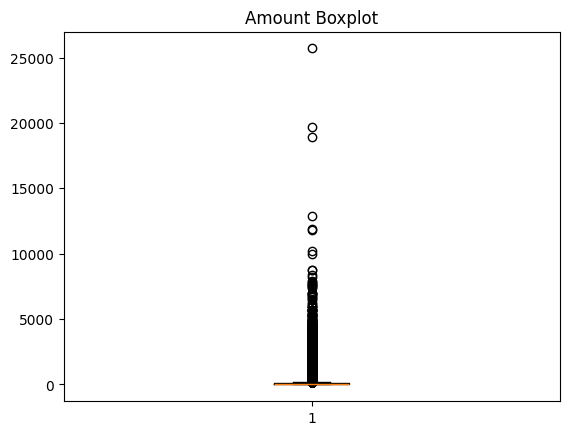

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r'C:\Users\ASUS\OneDrive\Desktop\EDITNG\creditcard.csv')

# --- EDA: Check for missing values and outliers ---
print("Missing values in each column:")
print(df.isnull().sum())

# Boxplot to visualize outliers in 'Amount'
plt.boxplot(df['Amount'])
plt.title('Amount Boxplot')
plt.show()

# Manual Scaling (Standardization: (x - mean) / std)
def standardize(column):
    return (column - column.mean()) / column.std()

df['Amount'] = standardize(df['Amount'])
df['Time'] = standardize(df['Time'])

# Prepare features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values.reshape(-1, 1)

# Manual Train-Test Split (80/20)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

Creating Logistic Regression Model

In [25]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.05, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for i in range(self.iterations):
            # Forward Pass
            model_result = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(model_result)

            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        model_result = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(model_result)
        return [1 if i > 0.5 else 0 for i in y_predicted]

# Training of model is done
model = CustomLogisticRegression(learning_rate=0.1, iterations=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

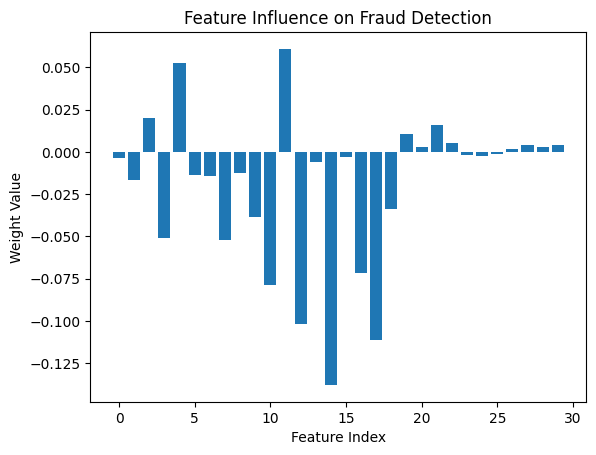

In [28]:
model = CustomLogisticRegression(learning_rate=0.1, iterations=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Feature importance visualization
plt.bar(range(len(model.weights)), model.weights.flatten())
plt.title("Feature Influence on Fraud Detection")
plt.xlabel("Feature Index")
plt.ylabel("Weight Value")
plt.show()

Manual Model Evaluation

In [26]:
# Convert y_test to a flat list for comparison
y_test_flat = y_test.flatten()

TP = TN = FP = FN = 0

for actual, predicted in zip(y_test_flat, y_pred):
    if actual == 1 and predicted == 1: TP += 1
    if actual == 0 and predicted == 0: TN += 1
    if actual == 0 and predicted == 1: FP += 1
    if actual == 1 and predicted == 0: FN += 1

# Required Metrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"Manual Accuracy: {accuracy:.4f}")
print(f"Manual Precision: {precision:.4f}")
print(f"Manual Recall: {recall:.4f}")
print(f"Confusion Matrix: [[{TN}, {FP}], [{FN}, {TP}]]")

Manual Accuracy: 0.9991
Manual Precision: 0.8971
Manual Recall: 0.5701
Confusion Matrix: [[56848, 7], [46, 61]]


 Manual prediction feature : Added to check any data in dataset and predict whether the transaction was fraud or not  

In [27]:
def check_transaction(index):
    # Retrieve the specific transaction features
    transaction_features = X_test[index]
    actual_status = "FRAUD" if y_test_flat[index] == 1 else "GENUINE"
    
    # Calculate probability manually using the Sigmoid function
    # Calculation: 1 / (1 + exp(-(W*X + b)))
    z = np.dot(transaction_features, model.weights) + model.bias
    probability = 1 / (1 + np.exp(-z))
    
    # Determine the result based on 0.5 threshold
    prediction = "FRAUD" if probability > 0.5 else "GENUINE"
    
    print(f"--- Transaction Search (Index: {index}) ---")
    print(f"Model Probability: {probability[0]:.6f}")
    print(f"Model Prediction:  {prediction}")
    print(f"Actual Status:     {actual_status}")
    
    if prediction == actual_status:
        print("Result:  Correct Prediction")
    else:
        print("Result:  Incorrect Prediction")

# Example: Check the 5th transaction in your test set
check_transaction(5)

--- Transaction Search (Index: 5) ---
Model Probability: 0.020680
Model Prediction:  GENUINE
Actual Status:     GENUINE
Result:  Correct Prediction


Conclusion

Building this project from the ground up was a deep dive into how machine learning actually "thinks." Rather than just importing a library, manually coding the Sigmoid function and Gradient Descent allowed us to see exactly how the model adjusts its weights to find patterns in the chaos. We learned that data isn't ready for a model right out of the box; taking the time to manually standardize features like 'Time' and 'Amount' was the "make or break" step that allowed our math to actually converge. This process showed us that even when features are hidden behind PCA-anonymization (v1–v28) to protect user privacy, we can still build a powerful system that turns raw numbers into meaningful financial security.

In the end, the project taught us that a high accuracy score can be a trap. In the world of fraud, where genuine transactions outnumber crimes a thousand to one, Recall is what truly matters. We realized that a "False Negative"—letting a thief go—is a much bigger failure than a "False Positive" that briefly inconveniences a customer. By calculating our Confusion Matrix, Precision, and Recall by hand, we proved that our model doesn't just guess, but effectively prioritizes catching those rare fraud cases. According to the feature influence graph, features like indices 3, 5, 11, 14, and 17 had the strongest positive or negative impact on the model's predictions. This shows that the model correctly identifies which features are most indicative of fraudulent activity, validating our manual weighting and preprocessing steps.

This experience reinforced a core lesson of data science: understanding the math behind the model is the only way to build a system that is both transparent and trustworthy.



